## **Coefficient of Determination**

The coefficient of determination is a statistical measurement that examines how differences in one variable can be explained by the difference in a second variable, when predicting the outcome of a given event. In other words, this coefficient, which is more commonly known as R-squared (or R2), assesses how strong the linear relationship is between two variables, and is heavily relied on by researchers when conducting trend analysis. 

You can read more about this coefficient on the following websites:
* https://www.scribbr.com/statistics/correlation-coefficient/ 
* https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
* https://en.wikipedia.org/wiki/Coefficient_of_multiple_correlation

![https://cdn.scribbr.com/wp-content/uploads/2021/08/01-correlation-types-1024x415.png](https://cdn.scribbr.com/wp-content/uploads/2021/08/01-correlation-types-1024x415.png)


## **Let's start!**

One more short message at the beginning: 

*Below you will find some information about determining the coefficient of determination using the basic functions of the numpy library. The notebook contains basic theoretical information about calculating the coefficient of determination itself (also for functions of three variables) and examples of linearization of a simple data set.*

In [1]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
import scipy as sp

# Input data - I
x_I = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
y_I = np.array([20.4, 29.9, 35.8, 42.1, 43.9, 44.9, 48.2, 50.3, 51.0, 52.5, 54.0, 55.0])

# Input data - II
x_II = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_II = np.array([5.2, 12.9, 19.2, 39.2, 51.3, 62.8, 95.2, 139.4, 157.2, 184.2, 235.9])

---
### **Data review**
Presenting the data in graphical form will allow you to visually assess the correlation of the *x* and *y* variables.

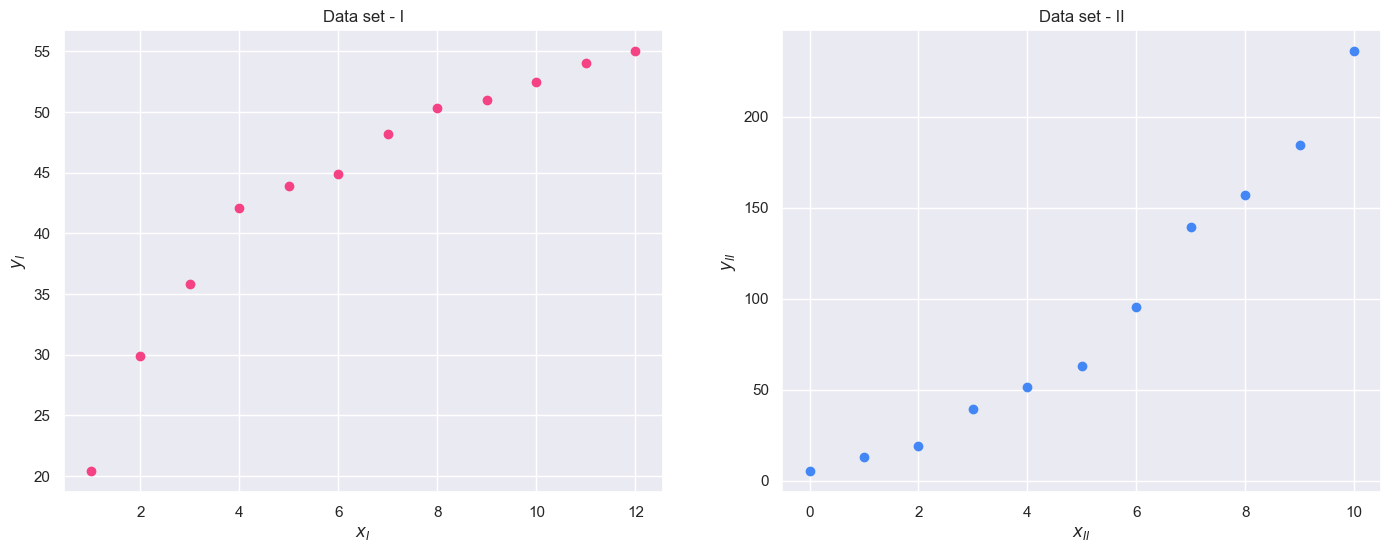

In [2]:
# Data visualization
fig = plt.figure(figsize = (17, 6))

plt.subplot(121)
plt.scatter(x_I, y_I, c = '#f54284')
plt.title('Data set - I')
plt.xlabel('$x_{I}$')
plt.ylabel('$y_{I}$')

plt.subplot(122)
plt.scatter(x_II, y_II, c = '#4287f5')
plt.title('Data set - II')
plt.xlabel('$x_{II}$')
plt.ylabel('$y_{II}$')

plt.subplots_adjust(wspace = 0.2)
plt.show()

The two data sets do not show a linear relationship. In order to determine the coefficients of determination for these series, the data must be linearized. The first data series shows a logarithmic relationship. The second shows a second-order polynomial dependence.

---
### **Linearization and calculation of the coefficient of determination for a logarithmic relationship**
To perform linearization, auxiliary parameters must be introduced:


$y = a \cdot log(x) + b$

$\underbrace{y}_{Y} = \underbrace{a}_{A}\underbrace{log(x)}_{X} + \underbrace{b}_{B}$

It follows from the above equation that new values of the parameter *X* should be determined (other parameters - unchanged). Below is a visualization of the data of series *I* after linearization calculations. 

In [3]:
# Linearization of the first data set
X_I = np.log(x_I)
Y_I = y_I

# Combination of the first series data after linearization
XY_I = np.concatenate((X_I.reshape((-1, 1)), Y_I.reshape((-1, 1))), axis = 1)
print(XY_I)

[[ 0.         20.4       ]
 [ 0.69314718 29.9       ]
 [ 1.09861229 35.8       ]
 [ 1.38629436 42.1       ]
 [ 1.60943791 43.9       ]
 [ 1.79175947 44.9       ]
 [ 1.94591015 48.2       ]
 [ 2.07944154 50.3       ]
 [ 2.19722458 51.        ]
 [ 2.30258509 52.5       ]
 [ 2.39789527 54.        ]
 [ 2.48490665 55.        ]]


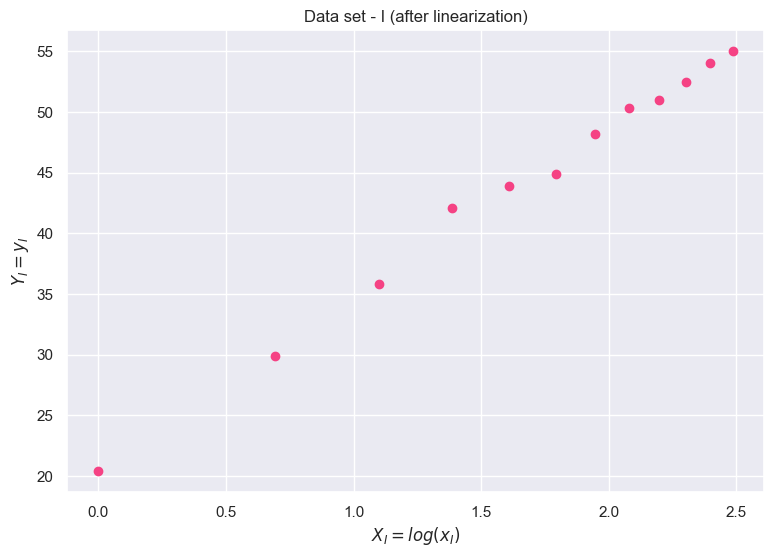

In [4]:
# Visualization of the first series after linearization
plt.figure(figsize = (9, 6))
plt.scatter(X_I, Y_I, c = '#f54284')

plt.title('Data set - I (after linearization)')
plt.xlabel('$X_{I}=log(x_{I})$')
plt.ylabel('$Y_{I}=y_{I}$')

plt.show()

Pearson correlation coefficient for two variables is given by the formula:

$R(X, Y) = 
\begin{bmatrix} \frac {cov(X,X)}{\sigma_{X}\sigma_{X}} & \frac {cov(X,Y)}{\sigma_{X}\sigma_{Y}} \\ \frac {cov(Y,X)}{\sigma_{Y}\sigma_{X}} & \frac {cov(Y,Y)}{\sigma_{Y}\sigma_{Y}} \end{bmatrix}$

$\ $

The value of the coefficient of determination for the first data series can be determined by the following equation:

$R^{2}(X, Y) = \begin{pmatrix} \frac {cov(X,Y)}{\sigma_{X}\sigma_{Y}} \end{pmatrix}^2 $

In [5]:
# Calculation of the Pearson correlation coefficient
R_XY_I = np.corrcoef(XY_I.T)
print(R_XY_I)

[[1.         0.99730365]
 [0.99730365 1.        ]]


In [6]:
# Calculation of the coefficient of determination
R2_XY_I = np.corrcoef(XY_I.T)[1, 0] ** 2
print(R2_XY_I)

0.9946145691869214


---
### **Linearization and calculation of the coefficient of determination for a second-order polynomial relationship**
To perform linearization, auxiliary parameters must be introduced:


$y = ax^2 + bx + c$

$\underbrace{y}_{Z} = \underbrace{a}_{A}\underbrace{x^2}_{X} + \underbrace{b}_{B}\underbrace{x}_{Y} + \underbrace{c}_{C}$

Based on the above notations, new values for the auxiliary parameters *X*, *Y*, *Z* can be determined. After linearization, the obtained relationship will be based on three variables.

In [7]:
# Linearization of the second data set
Z_II = y_II
X_II = x_II ** 2
Y_II = x_II

# Combination of the second series data after linearization
XYZ_II = np.concatenate((X_II.reshape((-1, 1)), Y_II.reshape((-1, 1)), Z_II.reshape((-1, 1))), axis = 1)
print(XYZ_II)

[[  0.    0.    5.2]
 [  1.    1.   12.9]
 [  4.    2.   19.2]
 [  9.    3.   39.2]
 [ 16.    4.   51.3]
 [ 25.    5.   62.8]
 [ 36.    6.   95.2]
 [ 49.    7.  139.4]
 [ 64.    8.  157.2]
 [ 81.    9.  184.2]
 [100.   10.  235.9]]


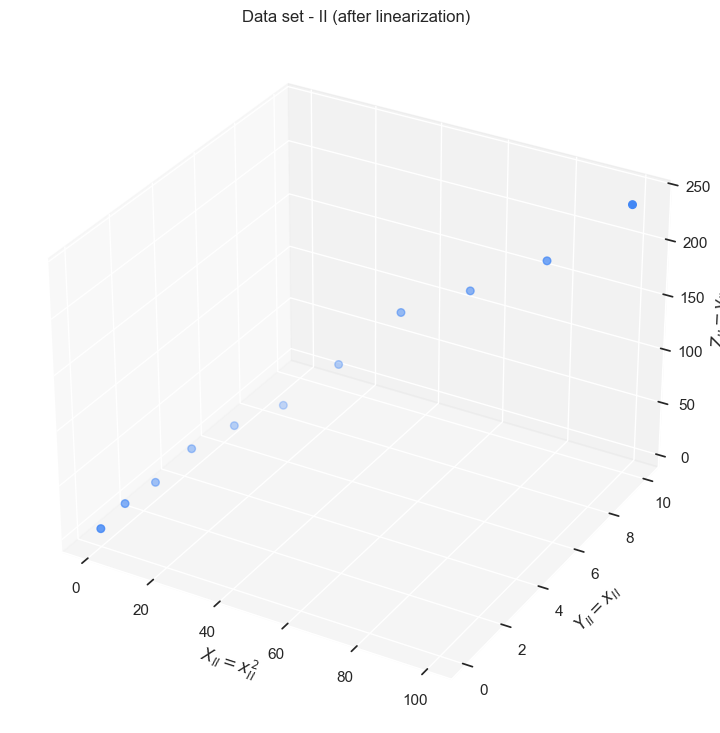

In [8]:
# Visualization of the second series of data after linearization
fig = plt.figure(figsize = (11, 9))
ax = fig.add_subplot(projection = '3d')

ax.scatter(X_II, Y_II, Z_II, c = '#4287f5', s = 30)
ax.set(xlabel = '$X_{II}=x_{II}^{2}$', 
       ylabel = '$Y_{II}=x_{II}$', 
       zlabel = '$Z_{II}=y_{II}$', 
       title = 'Data set - II (after linearization)', 
       facecolor = 'white')

plt.show()

The correlation matrix for the relationship of the three variables *X*, *Y*, *Z* looks different than in the previously analyzed example. The presence of complex relationships between the variables makes it necessary to calculate the coefficient of determination in this case using matrix algebra.


$\\$
$R(X, Y, Z) = 
\begin{bmatrix} \frac {cov(X,X)}{\sigma_{X}\sigma_{X}} & \frac {cov(X,Y)}{\sigma_{X}\sigma_{Y}} & \frac {cov(X,Z)}{\sigma_{X}\sigma_{Z}} \\ \frac {cov(Y,X)}{\sigma_{Y}\sigma_{X}} & \frac {cov(Y,Y)}{\sigma_{Y}\sigma_{Y}} & \frac {cov(Y,Z)}{\sigma_{Y}\sigma_{Z}} \\ \frac {cov(Z,X)}{\sigma_{Z}\sigma_{X}} & \frac {cov(Z,Y)}{\sigma_{Z}\sigma_{Y}} & \frac {cov(Z,Z)}{\sigma_{Z}\sigma_{Z}}
\end{bmatrix}$

$R^{2}(X, Y, Z) = 
\begin{bmatrix} \frac {cov(Z,X)}{\sigma_{Z}\sigma_{X}} & \frac {cov(Z,Y)}{\sigma_{Z}\sigma_{Y}} \end{bmatrix} 
\cdot
\begin{bmatrix} \frac {cov(X,X)}{\sigma_{X}\sigma_{X}} & \frac {cov(X,Y)}{\sigma_{X}\sigma_{Y}} \\ 
                \frac {cov(Y,X)}{\sigma_{Y}\sigma_{X}} & \frac {cov(Y,Y)}{\sigma_{Y}\sigma_{Y}} 
\end{bmatrix}^{-1} 
\cdot
\begin{bmatrix} \frac {cov(Z,X)}{\sigma_{Z}\sigma_{X}} \\ \frac {cov(Z,Y)}{\sigma_{Z}\sigma_{Y}} \end{bmatrix}$


In [9]:
# Calculation of the Pearson correlation coefficient
R_XYZ_II = np.corrcoef(XYZ_II.T)
print(R_XYZ_II)

[[1.         0.96314266 0.99549515]
 [0.96314266 1.         0.97118136]
 [0.99549515 0.97118136 1.        ]]


In [10]:
# Calculation of the coefficient of determination
R2_XYZ_II = R_XYZ_II[2, :2] @ np.linalg.inv(R_XYZ_II[:2, :2]) @ R_XYZ_II[2, :2].T
print(R2_XYZ_II)

0.9931279389484555


---
### **Using the linear regression model _sklearn.linear_model_**

Instead of manually calculating the coefficients of determination - directly from the definitions / formulas of this parameter, you can speed up the work, using the linear regression model from scikit-learn.

In [11]:
from sklearn.linear_model import LinearRegression

Below, as a reminder, the mathematical equations of the logarithmic relationship:

$y = a \cdot log(x) + b$

$\underbrace{y}_{Y} = \underbrace{a}_{A}\underbrace{log(x)}_{X} + \underbrace{b}_{B}$

In [12]:
# Create the model with the first data series
model_I = LinearRegression().fit(XY_I[:, :1], XY_I[:, 1:2])

In [13]:
# Display equation constants and coefficient of determination
R2_I = model_I.score(XY_I[:, :1], XY_I[:, 1:2])
a_I = model_I.coef_[:, 0]
b_I = model_I.intercept_

print('Data set I:')
print('R2 = ', R2_I)
print('a  = ', a_I)
print('b  = ', b_I)

Data set I:
R2 =  0.994614569186921
a  =  [13.93570647]
b  =  [20.78867047]


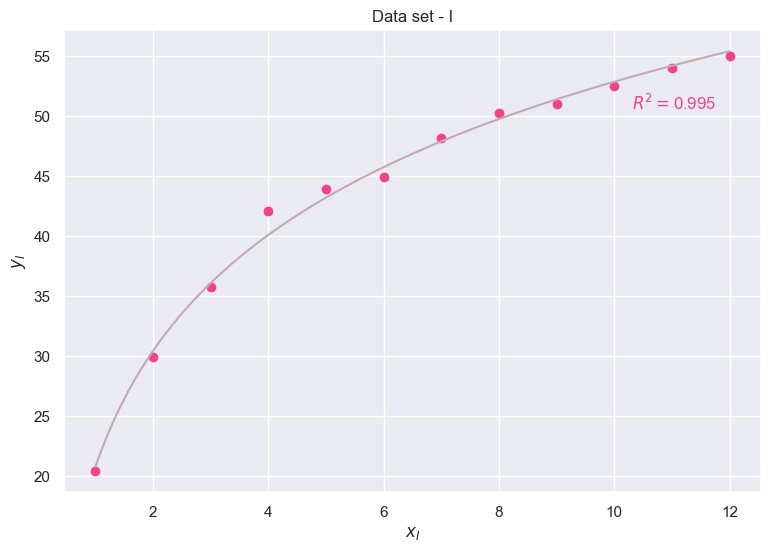

In [14]:
# Visualization of results - data set I
def line_y_I(x):
    a_I = model_I.coef_[:, 0]
    b_I = model_I.intercept_
   
    return a_I * np.log(x) + b_I

fig = plt.figure(figsize = (9, 6))
plt.plot(np.linspace(1, 12, 100), line_y_I(np.linspace(1, 12, 100)), c = '#c4a9b3')
plt.scatter(x_I, y_I, c = '#f54284')

plt.title('Data set - I')
plt.xlabel('$x_{I}$')
plt.ylabel('$y_{I}$')
plt.text(10.3, 50.5, '$R^{2}=$' + str(round(R2_I, 3)), c = '#f54284')

plt.show()

Analogous operations can be performed for data in which there is a polynomial dependence of the second degree.

$y = ax^2 + bx + c$

$\underbrace{y}_{Z} = \underbrace{a}_{A}\underbrace{x^2}_{X} + \underbrace{b}_{B}\underbrace{x}_{Y} + \underbrace{c}_{C}$

In [15]:
# Create the model with the second data series
model_II  = LinearRegression().fit(XYZ_II[:, :2], XYZ_II[:, 2:3])

In [16]:
# Display equation constants and coefficient of determination
R2_II = model_II.score(XYZ_II[:, :2], XYZ_II[:, 2:3])
a_II = model_II.coef_[:, 0]
b_II = model_II.coef_[:, 1]
c_II = model_II.intercept_

print('Data set II:')
print('R2 = ', R2_II)
print('a = ', a_II)
print('b = ', b_II)
print('c = ', c_II)

Data set II:
R2 =  0.9931279389484569
a =  [1.87016317]
b =  [3.9983683]
c =  [5.68881119]


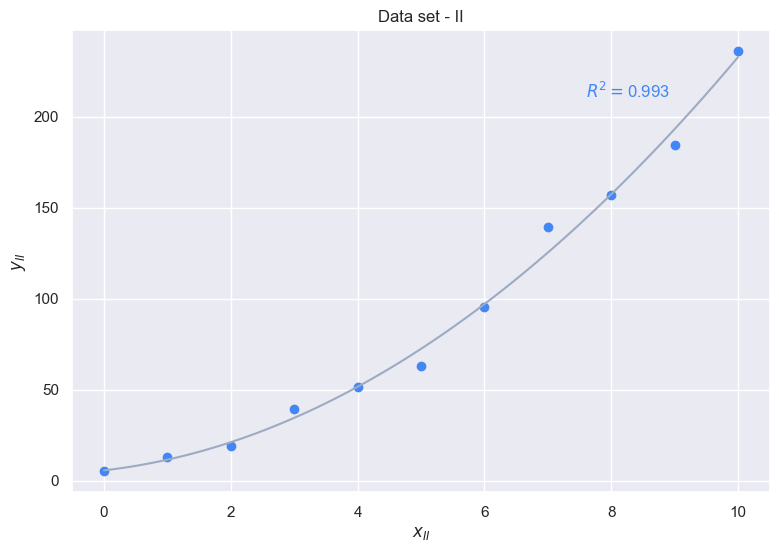

In [17]:
# Visualization of results - data set II
def line_y_II(x):
    a_II = model_II.coef_[:, 0]
    b_II = model_II.coef_[:, 1]
    c_II = model_II.intercept_
   
    return a_II * x ** 2 + b_II * x + c_II

fig = plt.figure(figsize = (9, 6))
plt.plot(np.linspace(0, 10, 100), line_y_II(np.linspace(0, 10, 100)), c = '#9dabc2')
plt.scatter(x_II, y_II, c = '#4287f5')

plt.title('Data set - II')
plt.xlabel('$x_{II}$')
plt.ylabel('$y_{II}$')
plt.text(7.6, 210, '$R^{2}=$' + str(round(R2_II, 3)), c = '#4287f5')

plt.show()